# Bitcoin Direction Prediction

This notebook walks through the finished project for predicting whether BTC/USDT closes higher after **1 day, 5 days, or 7 days**.

The primary experiment uses a repeating 10-week interleaved split across the full timeline: training weeks **1, 2, 4, 7, 9, 10**, validation weeks **3, 6**, and test weeks **5, 8**. Calendar weeks run Monday through Sunday.

The full training pipeline is implemented in `src/bitcoin_direction/`. Predictions are for an academic portfolio project, not financial advice.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from bitcoin_direction.config import ARTIFACTS_DIR, DATA_PATH
from bitcoin_direction.features import load_raw_data, create_feature_table, repeating_week_split_indices
from bitcoin_direction.inference import predict_latest

pd.set_option("display.max_columns", 100)

## 1. Load and validate the daily Binance data

In [2]:
raw = load_raw_data(str(DATA_PATH))
print(f"Rows: {len(raw):,}")
print(f"Period: {raw['date'].min().date()} to {raw['date'].max().date()}")
print(f"Missing values: {int(raw.isna().sum().sum())}")
raw.head()

Rows: 3,089
Period: 2018-01-01 to 2026-06-16
Missing values: 0


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,date
0,2018-01-01 00:00:00.000000 UTC,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0,2018-01-01 00:00:00+00:00
1,2018-01-02 00:00:00.000000 UTC,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0,2018-01-02 00:00:00+00:00
2,2018-01-03 00:00:00.000000 UTC,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0,2018-01-03 00:00:00+00:00
3,2018-01-04 00:00:00.000000 UTC,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000 UTC,3.127816e+08,170310,12680.812951,1.861168e+08,0,2018-01-04 00:00:00+00:00
4,2018-01-05 00:00:00.000000 UTC,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000 UTC,3.693220e+08,192969,13346.622293,2.118299e+08,0,2018-01-05 00:00:00+00:00


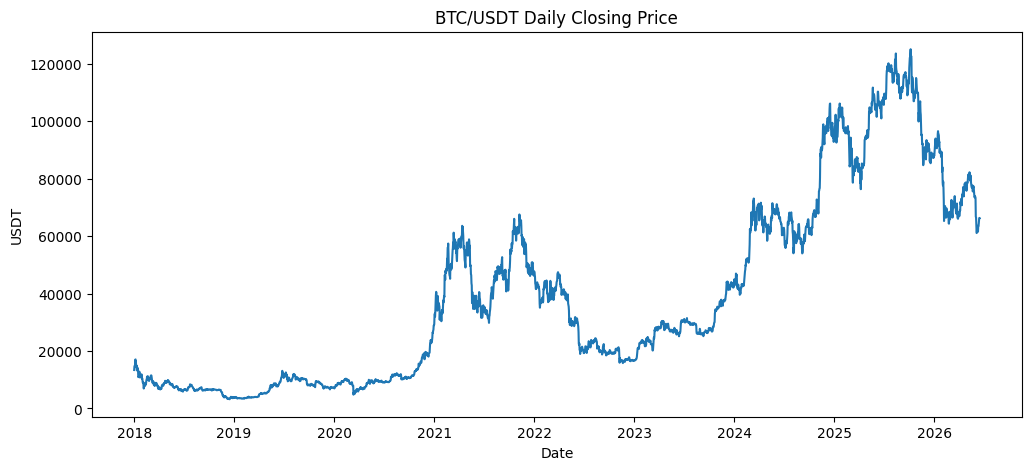

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(raw["date"], raw["close"])
plt.title("BTC/USDT Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("USDT")
plt.show()

## 2. Create leakage-safe features and labels

The features use only information available at or before day `t`. The targets compare the current close with the close after 1, 5 and 7 days.

In [4]:
featured, feature_columns = create_feature_table(raw, drop_unlabeled=True)
train_idx, validation_idx, test_idx, assignments = repeating_week_split_indices(
    featured["date"], anchor_date=raw["date"].min()
)
featured = pd.concat([featured, assignments], axis=1)

print(f"Model rows: {len(featured):,}")
print(f"Feature count: {len(feature_columns)}")
print(f"Train rows: {len(train_idx):,} ({len(train_idx) / len(featured):.1%})")
print(f"Validation rows: {len(validation_idx):,} ({len(validation_idx) / len(featured):.1%})")
print(f"Test rows: {len(test_idx):,} ({len(test_idx) / len(featured):.1%})")
featured[["date", "cycle_week", "split", "close", "target_1d", "target_5d", "target_7d"]].tail(20)


Model rows: 2,883
Feature count: 66
Train rows: 1,735 (60.2%)
Validation rows: 574 (19.9%)
Test rows: 574 (19.9%)


,date,cycle_week,split,close,target_1d,target_5d,target_7d
2863,2026-05-21 00:00:00+00:00,8,test,77615.52,0,0,0
2864,2026-05-22 00:00:00+00:00,8,test,75539.50,1,0,0
2865,2026-05-23 00:00:00+00:00,8,test,76752.01,1,0,0
2866,2026-05-24 00:00:00+00:00,8,test,77064.96,1,0,0
2867,2026-05-25 00:00:00+00:00,9,train,77322.01,0,0,0
2868,2026-05-26 00:00:00+00:00,9,train,75930.01,0,0,0
2869,2026-05-27 00:00:00+00:00,9,train,74449.30,0,0,0
2870,2026-05-28 00:00:00+00:00,9,train,73617.51,0,0,0
2871,2026-05-29 00:00:00+00:00,9,train,73460.78,1,0,0
2872,2026-05-30 00:00:00+00:00,9,train,73884.38,0,0,0


In [5]:
target_balance = pd.DataFrame({
    "next_day": featured["target_1d"].value_counts(normalize=True).sort_index(),
    "next_5_days": featured["target_5d"].value_counts(normalize=True).sort_index(),
    "next_week": featured["target_7d"].value_counts(normalize=True).sort_index(),
}).rename(index={0: "DOWN", 1: "UP"})
target_balance

,next_day,next_5_days,next_week
DOWN,0.492542,0.46965,0.469997
UP,0.507458,0.53035,0.530003


## 3. Inspect repeating-week validation and test results


In [6]:
results = pd.read_csv(ARTIFACTS_DIR / "results" / "model_results.csv")
results[[
    "horizon_name", "model", "split", "accuracy", "balanced_accuracy",
    "precision", "recall", "f1", "roc_auc", "threshold"
]].sort_values(["horizon_name", "split", "roc_auc"], ascending=[True, True, False])

,horizon_name,model,split,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,threshold
17,next_5_days,random_forest,test,0.529617,0.534227,0.579767,0.479100,0.524648,0.549839,0.505
23,next_5_days,lstm,test,0.531359,0.550799,0.634615,0.318328,0.423983,0.548519,0.525
19,next_5_days,xgboost,test,0.517422,0.493337,0.537611,0.781350,0.636959,0.534960,0.455
21,next_5_days,mlp,test,0.543554,0.528603,0.562660,0.707395,0.626781,0.529018,0.490
15,next_5_days,logistic_regression,test,0.491289,0.512061,0.565517,0.263666,0.359649,0.511780,0.565
13,next_5_days,majority_baseline,test,0.541812,0.500000,0.541812,1.000000,0.702825,0.500000,0.500
20,next_5_days,mlp,validation,0.571429,0.556671,0.591512,0.707937,0.644509,0.567359,0.490
22,next_5_days,lstm,validation,0.538596,0.557730,0.641618,0.355769,0.457732,0.553729,0.525
14,next_5_days,logistic_regression,validation,0.508711,0.530759,0.603774,0.304762,0.405063,0.515855,0.565
12,next_5_days,majority_baseline,validation,0.548780,0.500000,0.548780,1.000000,0.708661,0.500000,0.500


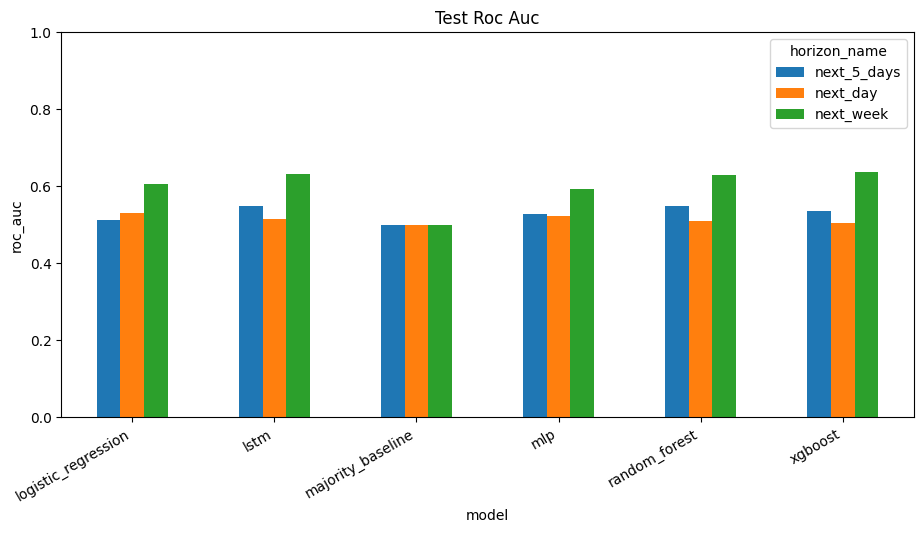

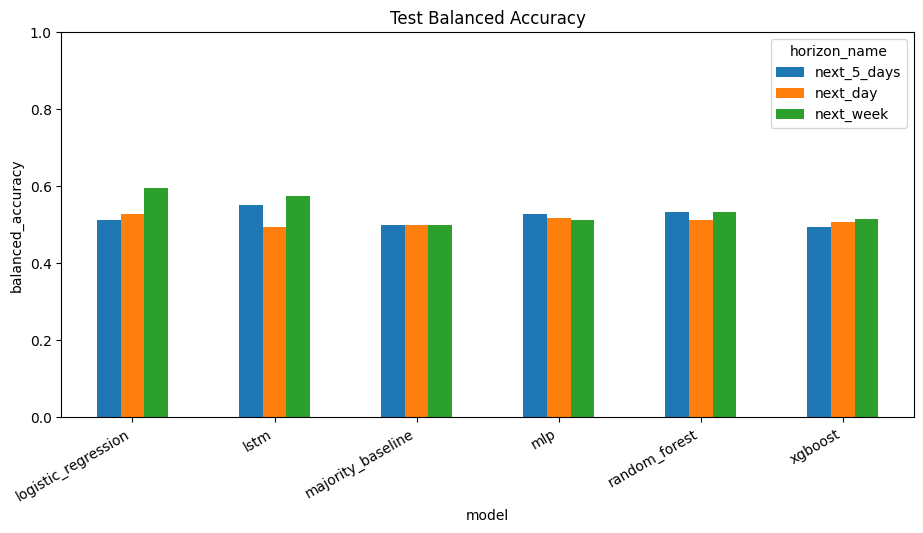

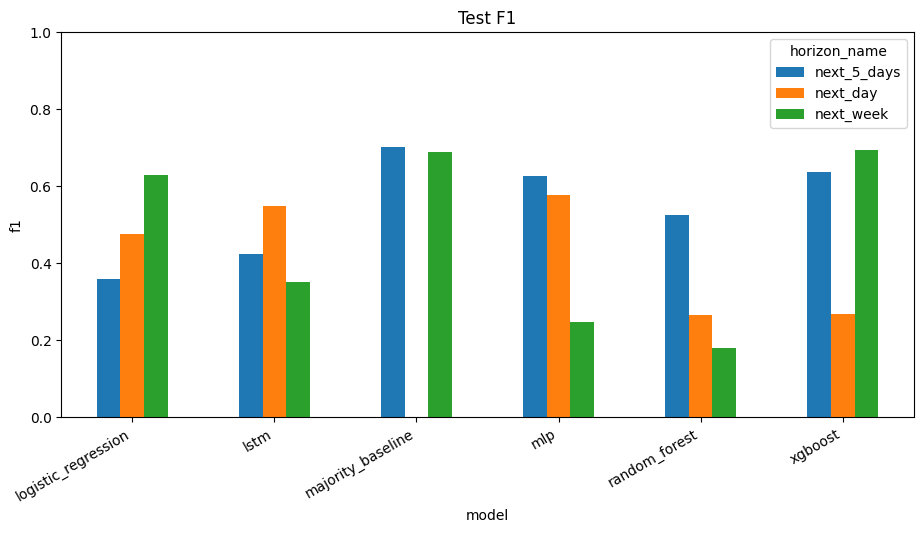

In [7]:
test_results = results[results["split"] == "test"]
for metric in ["roc_auc", "balanced_accuracy", "f1"]:
    pivot = test_results.pivot(index="model", columns="horizon_name", values=metric)
    pivot.plot(kind="bar", figsize=(11, 5), title=f"Test {metric.replace('_', ' ').title()}")
    plt.ylim(0, 1)
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.show()

### Interpretation

The interleaved split gives every partition coverage across the 2018–2026 timeline and measures whether patterns generalize to held-out weeks throughout multiple market regimes. However, it is **not** a strict future-only holdout because training weeks can occur after validation or test weeks. The separate expanding-window benchmark remains the stricter forecasting-oriented evaluation.


## 4. Expanding-window walk-forward benchmark

In [8]:
walk_forward = pd.read_csv(ARTIFACTS_DIR / "results" / "walk_forward_summary.csv")
walk_forward.sort_values(["horizon_name", "mean_roc_auc"], ascending=[True, False])

,horizon_days,horizon_name,model,mean_accuracy,std_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_f1,mean_roc_auc,std_roc_auc
4,5,next_5_days,random_forest,0.514815,0.037121,0.518140,0.029257,0.512497,0.518414,0.023613
3,5,next_5_days,logistic_regression,0.504630,0.046983,0.505029,0.029955,0.517060,0.496064,0.033016
5,5,next_5_days,xgboost,0.506481,0.016801,0.509999,0.013869,0.497272,0.493494,0.018650
0,1,next_day,logistic_regression,0.528704,0.023909,0.536966,0.023077,0.514521,0.538464,0.029922
2,1,next_day,xgboost,0.511574,0.019262,0.511654,0.018311,0.543186,0.528509,0.037420
1,1,next_day,random_forest,0.518981,0.037816,0.521006,0.039572,0.522814,0.524080,0.046080
7,7,next_week,random_forest,0.501389,0.052503,0.510312,0.045729,0.433987,0.514353,0.073975
6,7,next_week,logistic_regression,0.524074,0.042703,0.524128,0.017142,0.464140,0.511869,0.030404
8,7,next_week,xgboost,0.517130,0.060863,0.523732,0.038841,0.423709,0.499255,0.077228


## 5. Backtest the validation-selected model for each horizon

In [9]:
backtest_summary = pd.read_csv(ARTIFACTS_DIR / "results" / "backtest_summary.csv")
backtest_summary

,strategy_final_equity,buy_hold_final_equity,strategy_total_return,buy_hold_total_return,strategy_max_drawdown,buy_hold_max_drawdown,strategy_sharpe,number_of_periods,invested_fraction,horizon_days,horizon_name,model,threshold
0,1.365557,1.548445,0.365557,0.548445,-0.255999,-0.455409,0.681388,574,0.383275,1,next_day,logistic_regression,0.530
1,1.986332,2.532190,0.986332,1.532190,-0.438791,-0.450605,0.830708,164,0.689024,5,next_5_days,mlp,0.490
2,2.429321,1.548445,1.429321,0.548445,-0.005940,-0.376730,1.972846,82,0.146341,7,next_week,lstm,0.575


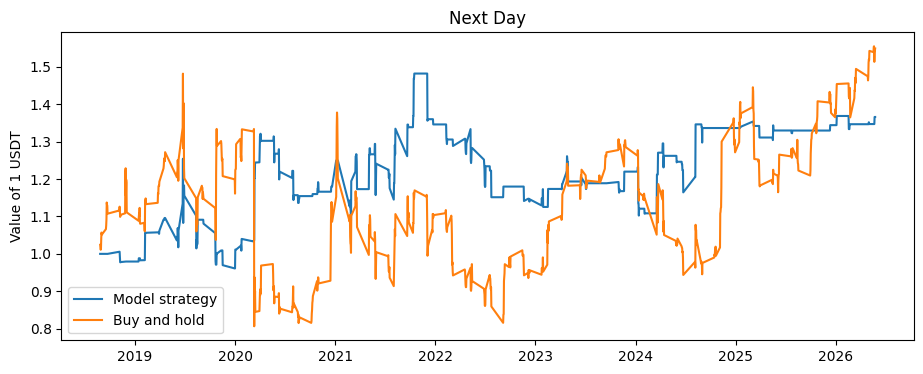

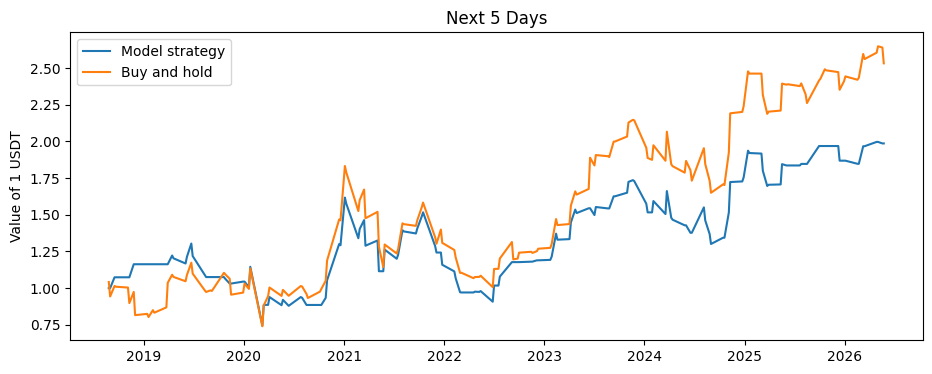

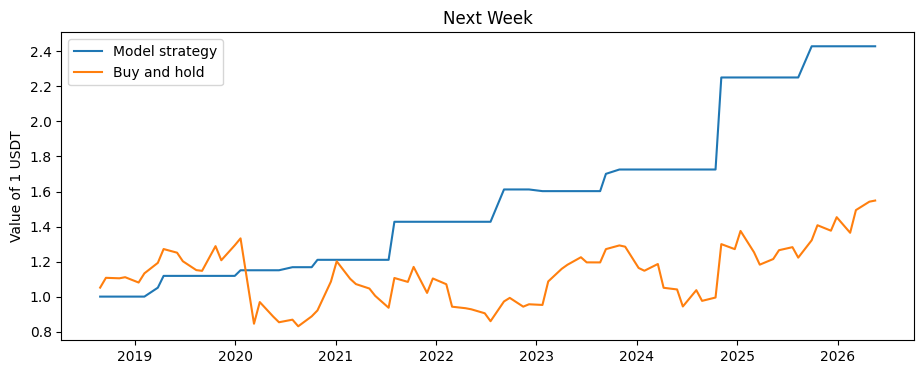

In [10]:
for horizon_name in ["next_day", "next_5_days", "next_week"]:
    backtest = pd.read_csv(ARTIFACTS_DIR / "backtests" / f"backtest_{horizon_name}.csv")
    plt.figure(figsize=(11, 4))
    plt.plot(pd.to_datetime(backtest["date"]), backtest["strategy_equity"], label="Model strategy")
    plt.plot(pd.to_datetime(backtest["date"]), backtest["buy_hold_equity"], label="Buy and hold")
    plt.title(horizon_name.replace("_", " ").title())
    plt.ylabel("Value of 1 USDT")
    plt.legend()
    plt.show()

## 6. Run the saved production models on the newest row

In [11]:
latest = predict_latest(DATA_PATH)
latest

,horizon,days,data_date,model,probability_up,threshold,prediction
0,next_day,1,2026-06-16,logistic_regression,0.502439,0.530,DOWN
1,next_5_days,5,2026-06-16,mlp,0.481494,0.490,DOWN
2,next_week,7,2026-06-16,lstm,0.501565,0.575,DOWN


## 7. Reproduce the full pipeline

```bash
python train.py
python walk_forward.py
python predict.py
streamlit run app.py
```

The training script uses the repeating 10-week split for model selection and evaluation, then refits only the validation-selected architecture on all labeled data for deployment. `walk_forward.py` provides an additional strict chronological benchmark for the classical models.


## 8. Recommended extensions

- Add funding rates, open interest and order-book imbalance.
- Add on-chain, sentiment and macroeconomic features.
- Detect market regimes and retrain on rolling windows.
- Calibrate probabilities and study threshold stability.
- Add the 4-hour dataset as a multi-timeframe feature source.
- Use nested walk-forward validation for hyperparameter selection.